# 🔍 Visualize quá trình phân loại biển báo — HOG + RF/SVM

Notebook này dùng để **nhìn rõ pipeline phân loại**:

1. Đọc ảnh gốc
2. Chuyển grayscale
3. Resize về đúng kích thước lúc train
4. Trích xuất đặc trưng HOG và hiển thị HOG image
5. Đưa vector HOG vào model
6. Hiển thị nhãn dự đoán, confidence / score và Top-k lớp gần nhất

> Đặt file notebook này trong thư mục: `notebook_demo/visualize_classification_process.ipynb`

In [52]:
from pathlib import Path

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import resize

## 1. Khai báo đường dẫn project

In [53]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "models").exists():
            return candidate
    return start

# Thu muc goc project (auto-detect).
# Neu can, mo comment va tu chi dinh:
# PROJECT_ROOT = Path(r"E:\\Duong\\Dan\\Project")
PROJECT_ROOT = find_project_root(Path.cwd())

DATA_DIR = PROJECT_ROOT / "data"
TEST_DIR = DATA_DIR / "test"
MODELS_DIR = PROJECT_ROOT / "models"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TEST_DIR     :", TEST_DIR)
print("MODELS_DIR   :", MODELS_DIR)

if not DATA_DIR.exists() or not MODELS_DIR.exists():
    raise FileNotFoundError(
        "Khong tim thay thu muc 'data' hoac 'models'. "
        "Hay kiem tra lai PROJECT_ROOT."
    )

PROJECT_ROOT: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification
TEST_DIR     : e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data\test
MODELS_DIR   : e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\models


## 2. Chọn model muốn visualize

In [54]:
MODEL_FILES = {
    "RF_6x3" : "HOG_RandomForest_6x3.joblib",
    "RF_8x2" : "HOG_RandomForest_8x2.joblib",
    "SVM_6x3": "HOG_SVM_6x3.joblib",
    "SVM_8x2": "HOG_SVM_8x2.joblib",
}

# Đổi key ở đây nếu muốn dùng model khác: RF_6x3, RF_8x2, SVM_6x3, SVM_8x2
MODEL_KEY = "SVM_6x3"
MODEL_PATH = MODELS_DIR / MODEL_FILES[MODEL_KEY]

payload = joblib.load(MODEL_PATH)

model      = payload["model"]
le         = payload["label_encoder"]
HOG_PARAMS = payload["hog_params"]
IMAGE_SIZE = tuple(payload["image_size"])
FEATURE_EXTRACTOR = payload.get("feature_extractor", "HOG")
HSV_HIST_BINS = payload.get("hsv_hist_bins")
if HSV_HIST_BINS is not None:
    HSV_HIST_BINS = tuple(HSV_HIST_BINS)

print(f"✅ Loaded model : {MODEL_KEY}")
print(f"✅ Model type   : {type(model).__name__}")
print(f"✅ Classes      : {list(le.classes_)}")
print(f"✅ Image size   : {IMAGE_SIZE}")
print(f"✅ HOG params   : {HOG_PARAMS}")
print(f"✅ Feature extractor : {FEATURE_EXTRACTOR}")
if HSV_HIST_BINS is not None:
    print(f"✅ HSV bins          : {HSV_HIST_BINS}")

✅ Loaded model : SVM_6x3
✅ Model type   : SVC
✅ Classes      : ['Cam', 'Chidan', 'Hieulenh', 'Nguyhiem', 'Phu']
✅ Image size   : (128, 128)
✅ HOG params   : {'orientations': 9, 'pixels_per_cell': (6, 6), 'cells_per_block': (3, 3), 'block_norm': 'L2-Hys'}
✅ Feature extractor : HOG_HSV
✅ HSV bins          : (16, 8, 8)


## 3. Chọn ảnh cần phân loại

In [55]:
# Cach 1: nhap truc tiep duong dan anh
IMAGE_PATH = TEST_DIR / "Nguyhiem" / "Nguyhiem_029.jpg"

# Cach 2: neu muon tu lay 1 anh dau tien trong thu muc test
# IMAGE_PATH = next(TEST_DIR.rglob("*.jpeg"))

if not IMAGE_PATH.exists():
    candidates = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
        candidates.extend(TEST_DIR.rglob(ext))
    if len(candidates) == 0:
        raise FileNotFoundError(
            "Khong tim thay anh trong data/test. "
            "Hay kiem tra lai TEST_DIR."
        )
    IMAGE_PATH = candidates[0]
    print("Canh bao: anh chi dinh khong ton tai, da chon anh dau tien:", IMAGE_PATH)

print("IMAGE_PATH:", IMAGE_PATH)

IMAGE_PATH: e:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data\test\Nguyhiem\Nguyhiem_029.jpg


## 4. Hàm xử lý ảnh và trích xuất HOG có visualize

In [56]:
def enhance_hog_image(hog_image: np.ndarray) -> np.ndarray:
    image = np.asarray(hog_image, dtype=np.float32)
    image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)
    image = np.maximum(image, 0.0)

    if float(image.max()) <= float(image.min()):
        return np.full((*image.shape, 3), 246, dtype=np.uint8)

    active = image[image > 0]
    if active.size == 0:
        return np.full((*image.shape, 3), 246, dtype=np.uint8)

    low = float(np.percentile(active, 5.0))
    high = float(np.percentile(active, 99.5))
    if high <= low:
        low = 0.0
        high = float(active.max())

    image = np.clip((image - low) / (high - low + 1e-8), 0.0, 1.0)
    image = np.power(image, 0.32)
    image_u8 = np.clip(image * 255.0, 0, 255).astype(np.uint8)
    image_u8 = cv2.dilate(image_u8, np.ones((2, 2), dtype=np.uint8), iterations=1)

    color_bgr = cv2.applyColorMap(image_u8, cv2.COLORMAP_TURBO)
    color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)
    canvas = np.full((*image_u8.shape, 3), 246, dtype=np.uint8)
    mask = image_u8 > 10
    alpha = (image_u8.astype(np.float32) / 255.0)[..., None]
    blended = canvas.astype(np.float32) * (1.0 - alpha) + color_rgb.astype(np.float32) * alpha
    canvas[mask] = blended[mask].astype(np.uint8)
    return canvas


def ensure_rgb(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        return np.stack([image] * 3, axis=-1)
    if image.shape[2] == 4:
        return image[:, :, :3]
    return image


def extract_hsv_histogram(
    image_rgb: np.ndarray,
    image_size: tuple[int, int],
    hsv_bins: tuple[int, int, int],
) -> np.ndarray:
    height, width = image_size
    rgb = ensure_rgb(image_rgb)
    if rgb.dtype != np.uint8:
        if rgb.max() <= 1.0:
            rgb_u8 = np.clip(rgb * 255.0, 0, 255).astype(np.uint8)
        else:
            rgb_u8 = np.clip(rgb, 0, 255).astype(np.uint8)
    else:
        rgb_u8 = rgb
    rgb_resized = cv2.resize(rgb_u8, (width, height), interpolation=cv2.INTER_AREA)
    hsv = cv2.cvtColor(rgb_resized, cv2.COLOR_RGB2HSV)
    h_bins, s_bins, v_bins = hsv_bins

    hist_h = cv2.calcHist([hsv], [0], None, [h_bins], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [s_bins], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [v_bins], [0, 256]).flatten()

    color_feature = np.concatenate([hist_h, hist_s, hist_v]).astype(np.float32)
    color_feature /= color_feature.sum() + 1e-8
    return color_feature


def preprocess_and_extract_hog(image_path, image_size, hog_params):
    """Return intermediate images for visualization."""
    img_original = imread(image_path)
    img_rgb = ensure_rgb(img_original)

    if img_original.ndim == 3:
        img_gray = rgb2gray(img_rgb)
    else:
        img_gray = img_original.astype(float)
        if img_gray.max() > 1:
            img_gray = img_gray / 255.0

    img_resized = resize(img_gray, image_size, anti_aliasing=True)

    features, hog_image = hog(
        img_resized,
        visualize=True,
        **hog_params
    )

    hog_image_enhanced = enhance_hog_image(hog_image)

    return {
        "original": img_rgb,
        "gray": img_gray,
        "resized": img_resized,
        "features": features,
        "hog_image": hog_image_enhanced,
        "image_rgb": img_rgb,
    }


def extract_model_feature(
    image_path,
    image_size,
    hog_params,
    feature_extractor="HOG",
    hsv_hist_bins=None,
    ):
    info = preprocess_and_extract_hog(image_path, image_size, hog_params)
    feature_parts = [info["features"].astype(np.float32)]
    extractor = str(feature_extractor).upper()
    if extractor == "HOG_HSV":
        if hsv_hist_bins is None:
            raise ValueError("Model expects HOG_HSV features but hsv_hist_bins is missing.")
        color_feature = extract_hsv_histogram(info["image_rgb"], image_size, hsv_hist_bins)
        feature_parts.append(color_feature)
    feature = np.concatenate(feature_parts)
    return feature, info


## 5. Visualize từng bước tiền xử lý + HOG

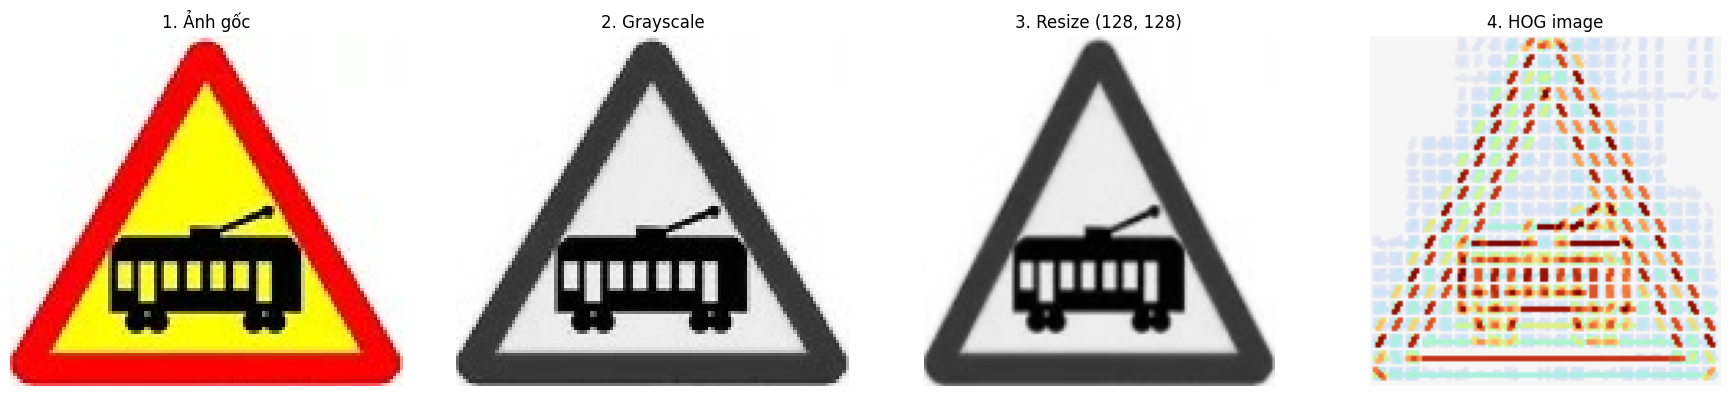

Số chiều vector HOG: 29241
10 giá trị HOG đầu tiên:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [57]:
info = preprocess_and_extract_hog(IMAGE_PATH, IMAGE_SIZE, HOG_PARAMS)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(info["original"])
axes[0].set_title("1. Ảnh gốc")
axes[0].axis("off")

axes[1].imshow(info["gray"], cmap="gray")
axes[1].set_title("2. Grayscale")
axes[1].axis("off")

axes[2].imshow(info["resized"], cmap="gray")
axes[2].set_title(f"3. Resize {IMAGE_SIZE}")
axes[2].axis("off")

axes[3].imshow(info["hog_image"])
axes[3].set_title("4. HOG image")
axes[3].axis("off")

plt.tight_layout()
plt.show()

print("Số chiều vector HOG:", info["features"].shape[0])
print("10 giá trị HOG đầu tiên:")
print(info["features"][:10])

## 6. Visualize vector đặc trưng HOG

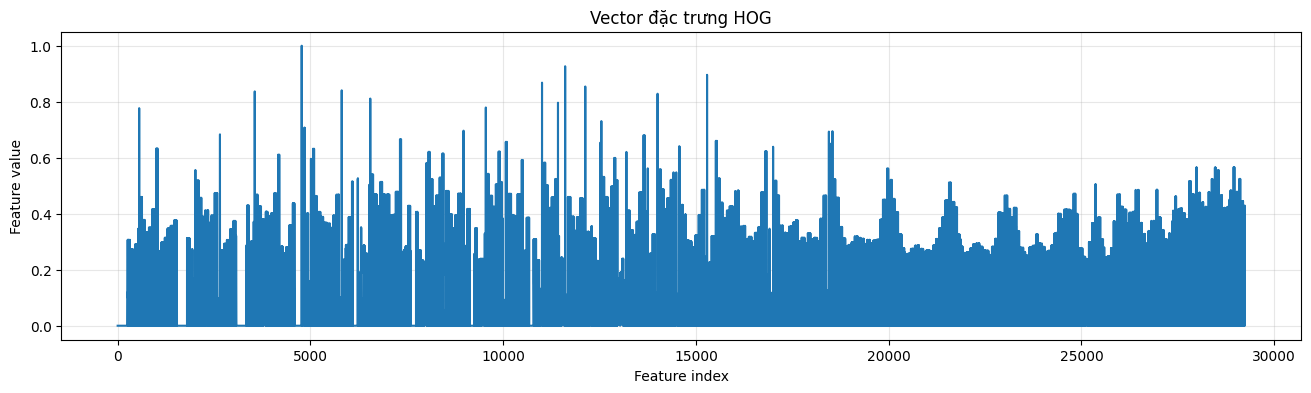

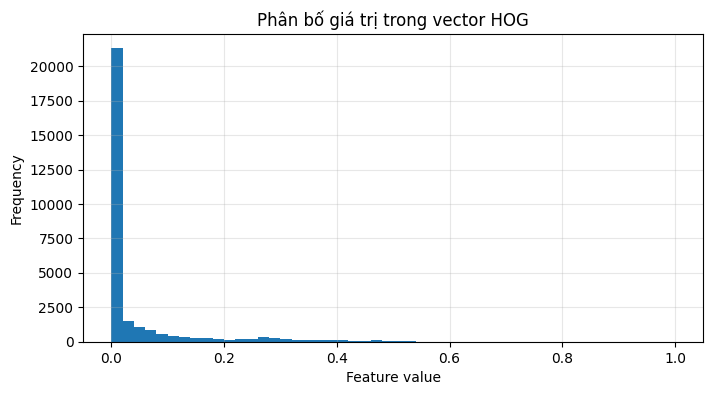

In [58]:
features = info["features"]

plt.figure(figsize=(16, 4))
plt.plot(features)
plt.title("Vector đặc trưng HOG")
plt.xlabel("Feature index")
plt.ylabel("Feature value")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(features, bins=50)
plt.title("Phân bố giá trị trong vector HOG")
plt.xlabel("Feature value")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Dự đoán và visualize score / probability

🏷️ Du doan: Nguyhiem
Loai score: probability
Top-5 lop:
1. Nguyhiem                       99.7939%
2. Chidan                         0.1070%
3. Hieulenh                       0.0921%
4. Cam                            0.0045%
5. Phu                            0.0026%


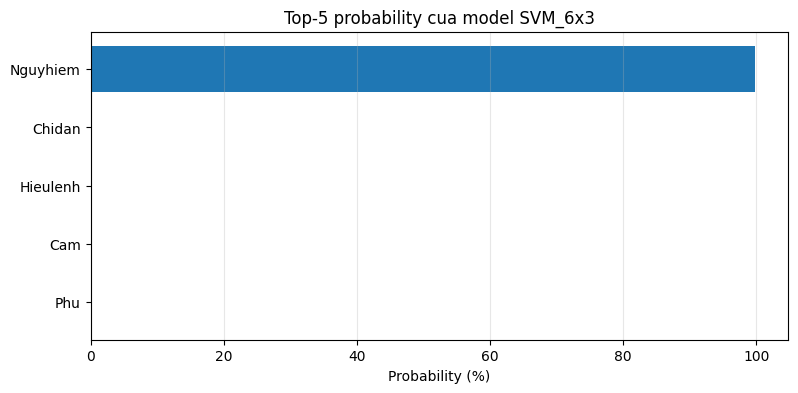

In [59]:
def get_model_scores(model, x):
    """
    RF thuong co predict_proba.
    SVM co the co predict_proba hoac decision_function.
    Ham nay chuan hoa output de ve Top-k.
    """
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(x)[0]
        score_type = "probability"
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(x)[0]
        if np.ndim(scores) == 0:
            scores = np.array([-scores, scores])
        score_type = "decision score"
    else:
        scores = None
        score_type = "none"
    return scores, score_type

feature_extractor = FEATURE_EXTRACTOR
hsv_hist_bins = HSV_HIST_BINS

model_feature, info = extract_model_feature(
    IMAGE_PATH,
    IMAGE_SIZE,
    HOG_PARAMS,
    feature_extractor,
    hsv_hist_bins,
    )
features = info["features"]

if hasattr(model, "n_features_in_") and model_feature.shape[0] != model.n_features_in_:
    raise ValueError(
        f"Feature length mismatch: got {model_feature.shape[0]}, "
        f"expected {model.n_features_in_}. "
        "Hay kiem tra lai HOG_PARAMS/IMAGE_SIZE va feature_extractor."
    )

x = model_feature.reshape(1, -1)
pred_enc = model.predict(x)[0]
pred_label = le.inverse_transform([pred_enc])[0]

scores, score_type = get_model_scores(model, x)

print(f"🏷️ Du doan: {pred_label}")
print(f"Loai score: {score_type}")

if scores is not None:
    top_k = min(5, len(scores))
    top_idx = np.argsort(scores)[::-1][:top_k]

    print(f"Top-{top_k} lop:")
    for rank, idx in enumerate(top_idx, start=1):
        label = le.inverse_transform([idx])[0]
        value = scores[idx]
        suffix = "%" if score_type == "probability" else ""
        shown_value = value * 100 if score_type == "probability" else value
        print(f"{rank}. {label:30s} {shown_value:.4f}{suffix}")

    labels = [le.inverse_transform([idx])[0] for idx in top_idx][::-1]
    values = [scores[idx] for idx in top_idx][::-1]
    if score_type == "probability":
        values = [v * 100 for v in values]

    plt.figure(figsize=(9, 4))
    plt.barh(labels, values)
    plt.title(f"Top-{top_k} {score_type} cua model {MODEL_KEY}")
    plt.xlabel("Probability (%)" if score_type == "probability" else "Decision score")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()
else:
    print("Model khong ho tro predict_proba hoac decision_function de visualize score.")

## 8. Gom toàn bộ pipeline vào một hàm visualize

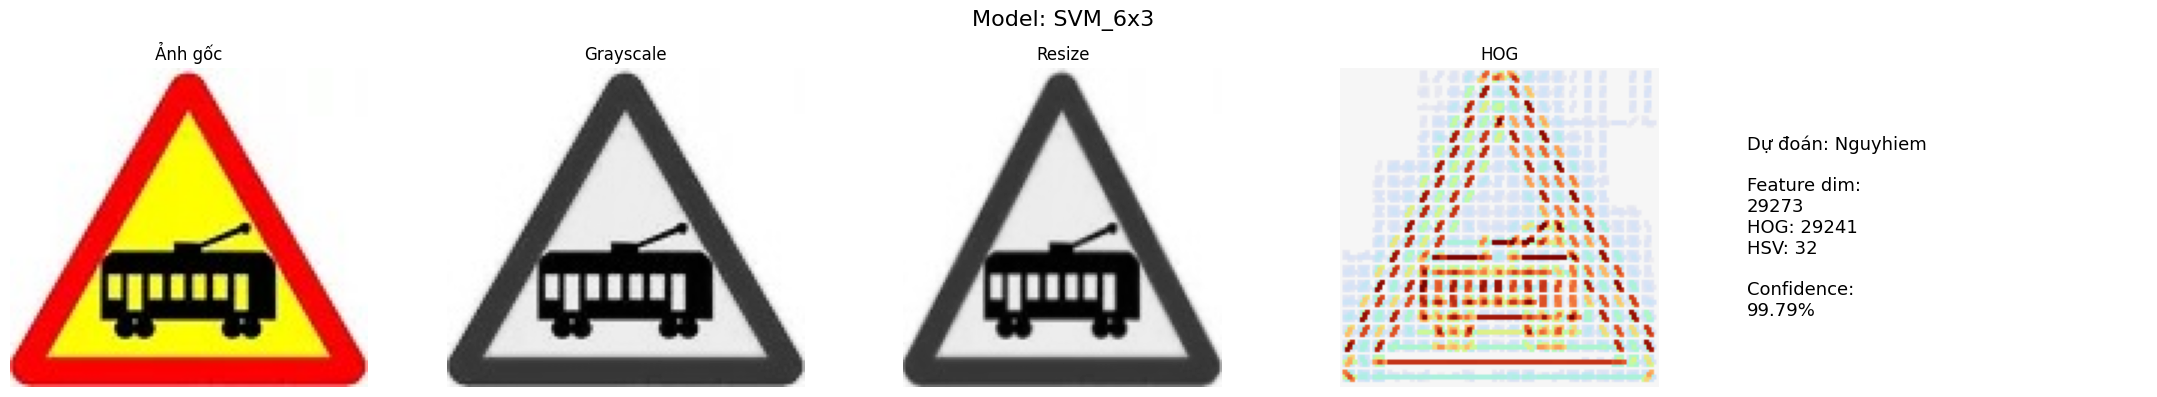

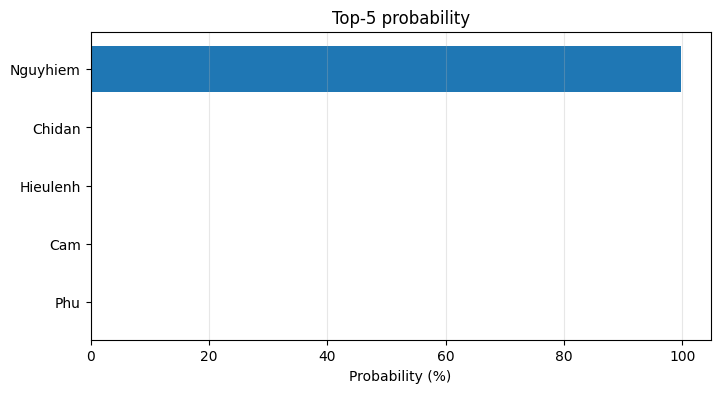

'Nguyhiem'

In [60]:
def visualize_classification(
    image_path,
    model,
    le,
    image_size,
    hog_params,
    feature_extractor="HOG",
    hsv_hist_bins=None,
    title=None,
    top_k=5,
    ):
    feature_vec, info = extract_model_feature(
        image_path,
        image_size,
        hog_params,
        feature_extractor,
        hsv_hist_bins,
    )
    x = feature_vec.reshape(1, -1)

    pred_enc = model.predict(x)[0]
    pred_label = le.inverse_transform([pred_enc])[0]
    scores, score_type = get_model_scores(model, x)

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))

    axes[0].imshow(info["original"])
    axes[0].set_title("Ảnh gốc")
    axes[0].axis("off")

    axes[1].imshow(info["gray"], cmap="gray")
    axes[1].set_title("Grayscale")
    axes[1].axis("off")

    axes[2].imshow(info["resized"], cmap="gray")
    axes[2].set_title("Resize")
    axes[2].axis("off")

    axes[3].imshow(info["hog_image"])
    axes[3].set_title("HOG")
    axes[3].axis("off")

    axes[4].axis("off")

    text = (
        f"Dự đoán: {pred_label}\n\n"
        f"Feature dim:\n{feature_vec.shape[0]}"
    )

    extractor = str(feature_extractor).upper()
    if extractor == "HOG_HSV":
        hog_dim = int(info["features"].shape[0])
        text += f"\nHOG: {hog_dim}\nHSV: {int(feature_vec.shape[0] - hog_dim)}"
    if scores is not None:
        if score_type == "probability":
            confidence = scores[pred_enc] * 100
            text += f"\n\nConfidence:\n{confidence:.2f}%"
        else:
            text += f"\n\nScore:\n{scores[pred_enc]:.4f}"

    axes[4].text(0.05, 0.5, text, fontsize=13, va="center")

    if title is None:
        title = Path(image_path).name

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

    if scores is not None:
        top_k = min(top_k, len(scores))
        top_idx = np.argsort(scores)[::-1][:top_k]

        labels = [le.inverse_transform([idx])[0] for idx in top_idx][::-1]
        values = [scores[idx] for idx in top_idx][::-1]

        if score_type == "probability":
            values = [v * 100 for v in values]

        plt.figure(figsize=(8, 4))
        plt.barh(labels, values)
        plt.title(f"Top-{top_k} {score_type}")
        plt.xlabel("Probability (%)" if score_type == "probability" else "Decision score")
        plt.grid(True, axis="x", alpha=0.3)
        plt.show()

    return pred_label


visualize_classification(
    IMAGE_PATH,
    model,
    le,
    IMAGE_SIZE,
    HOG_PARAMS,
    feature_extractor=FEATURE_EXTRACTOR,
    hsv_hist_bins=HSV_HIST_BINS,
    title=f"Model: {MODEL_KEY}",
)

## 9. Visualize nhiều ảnh trong thư mục test

Tìm thấy 6 ảnh để visualize


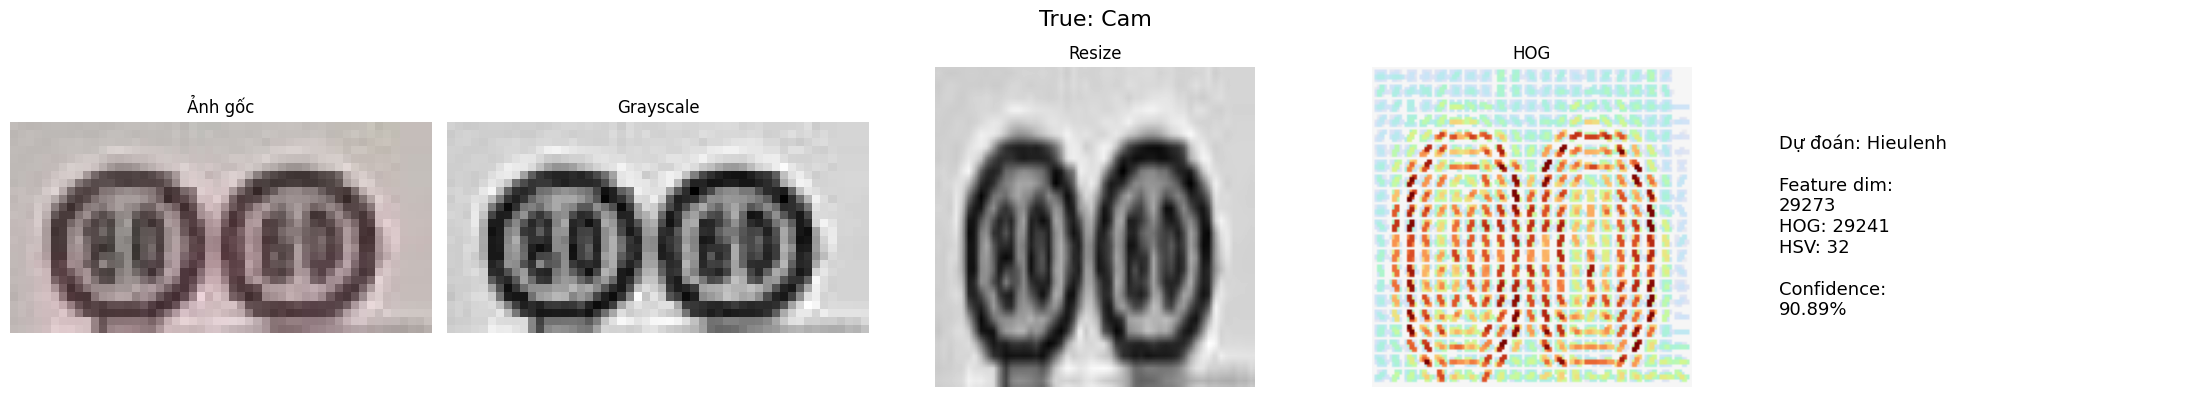

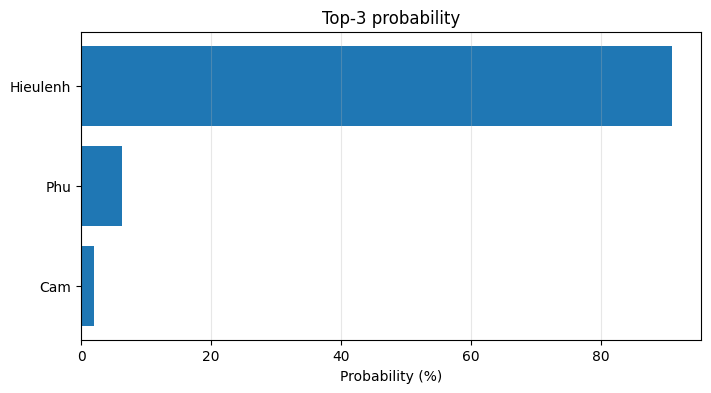

True: Cam | Pred: Hieulenh | File: Cam_001.jpg


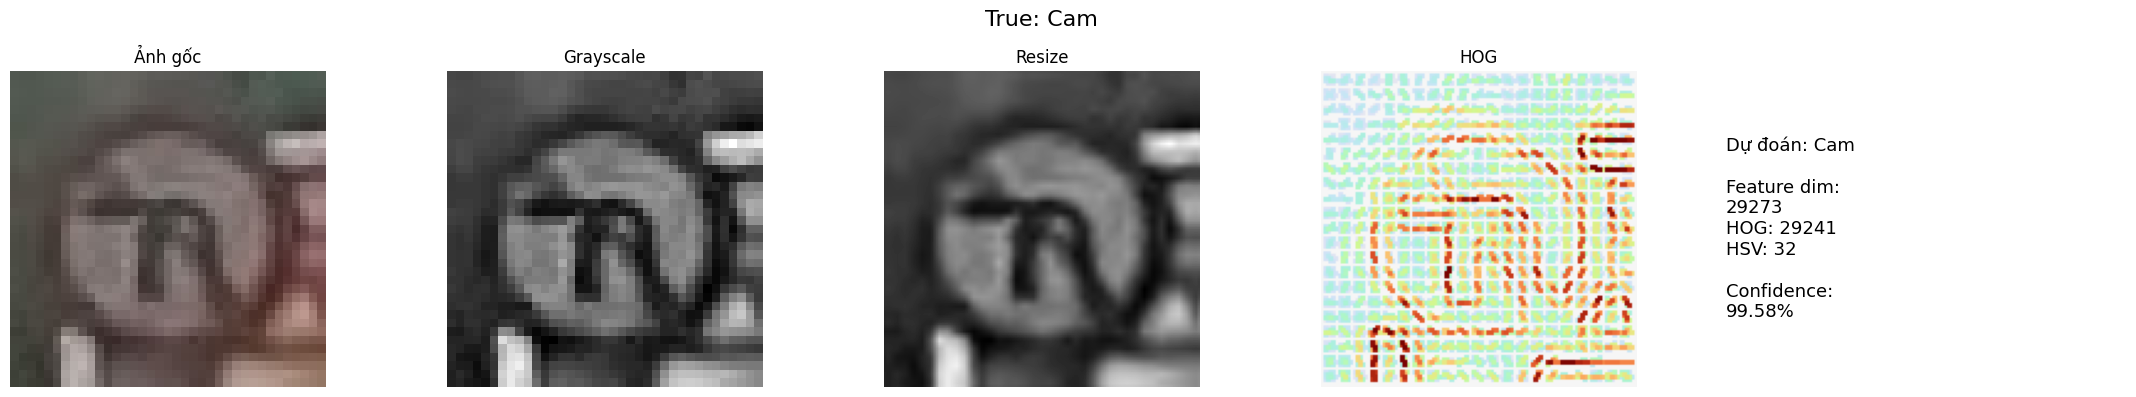

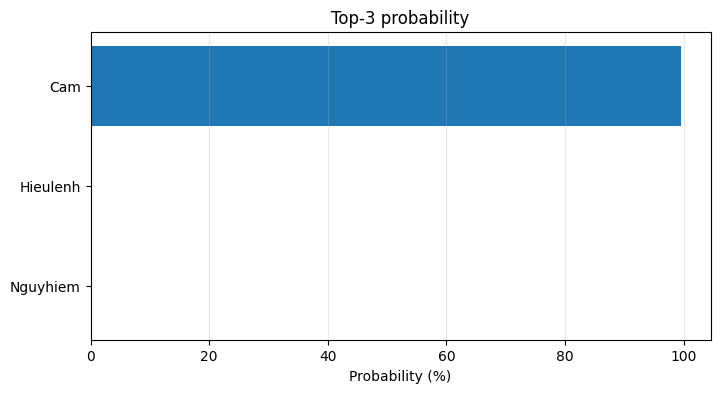

True: Cam | Pred: Cam | File: Cam_002.jpg


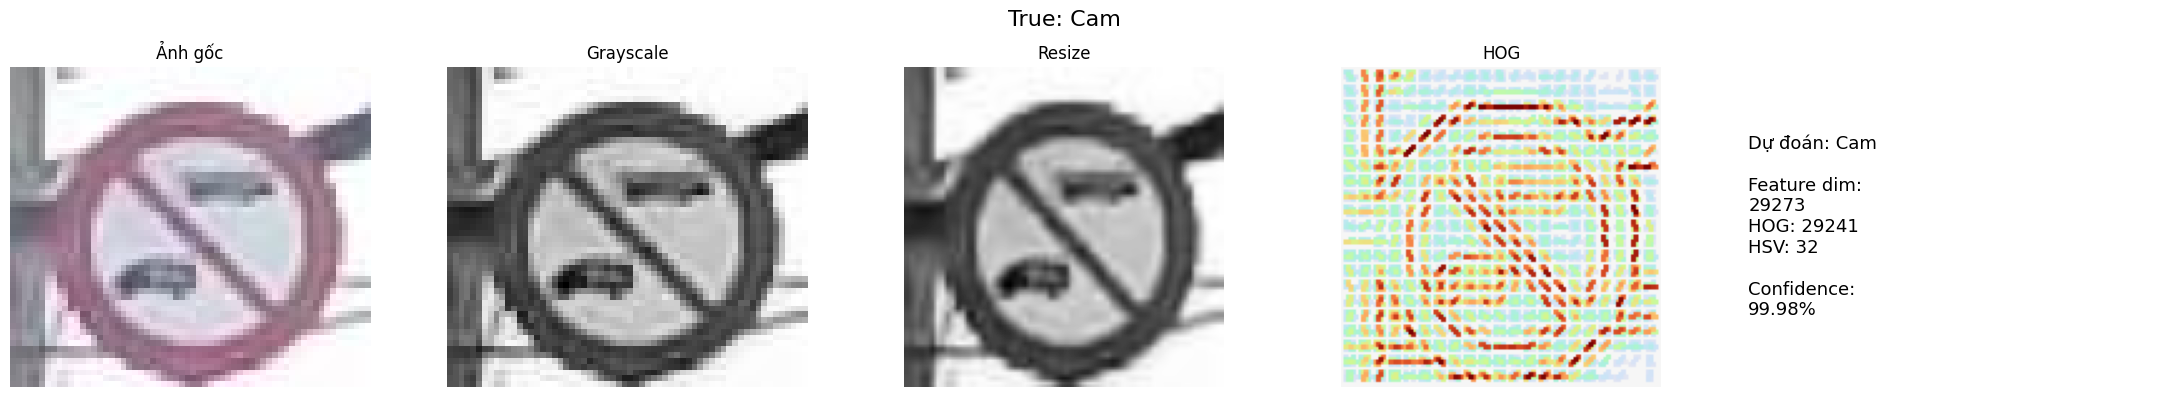

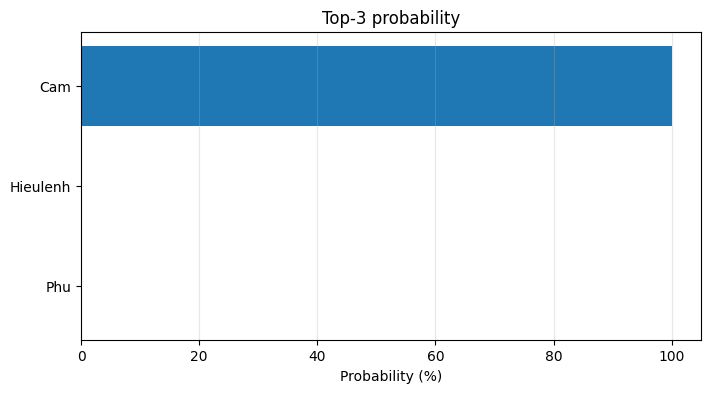

True: Cam | Pred: Cam | File: Cam_003.jpg


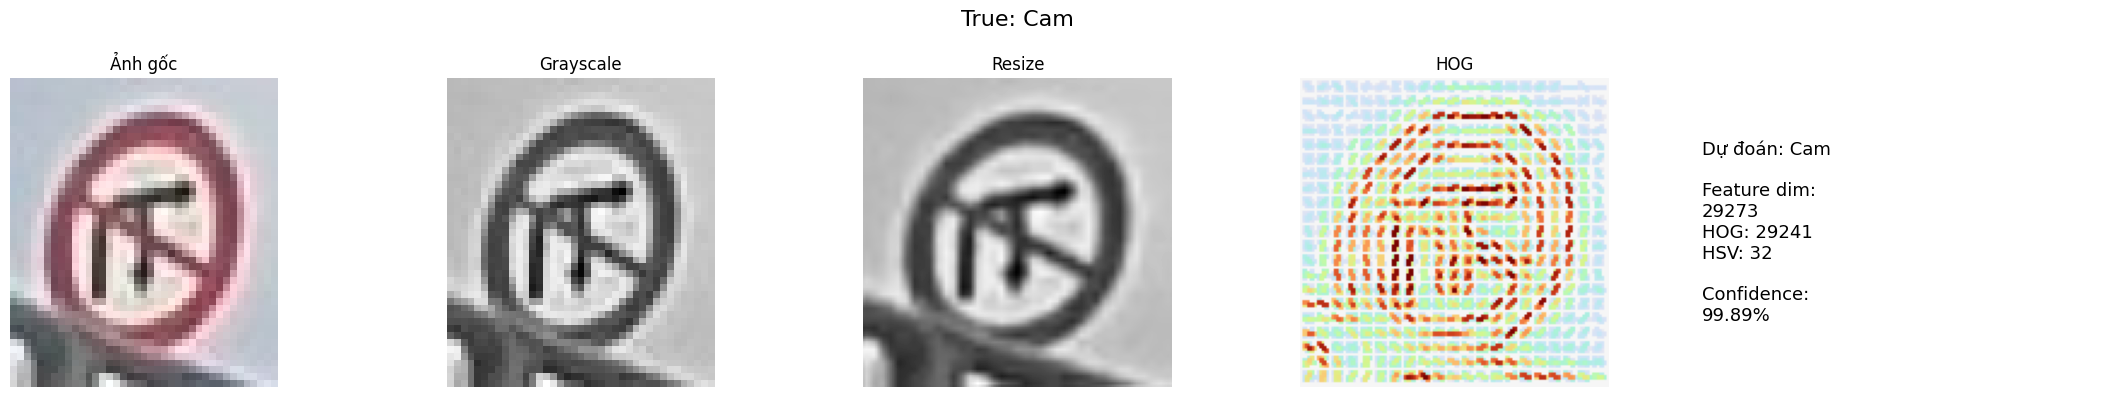

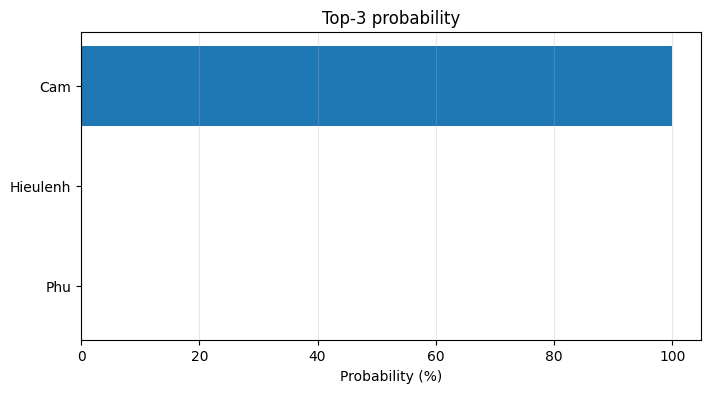

True: Cam | Pred: Cam | File: Cam_004.jpg


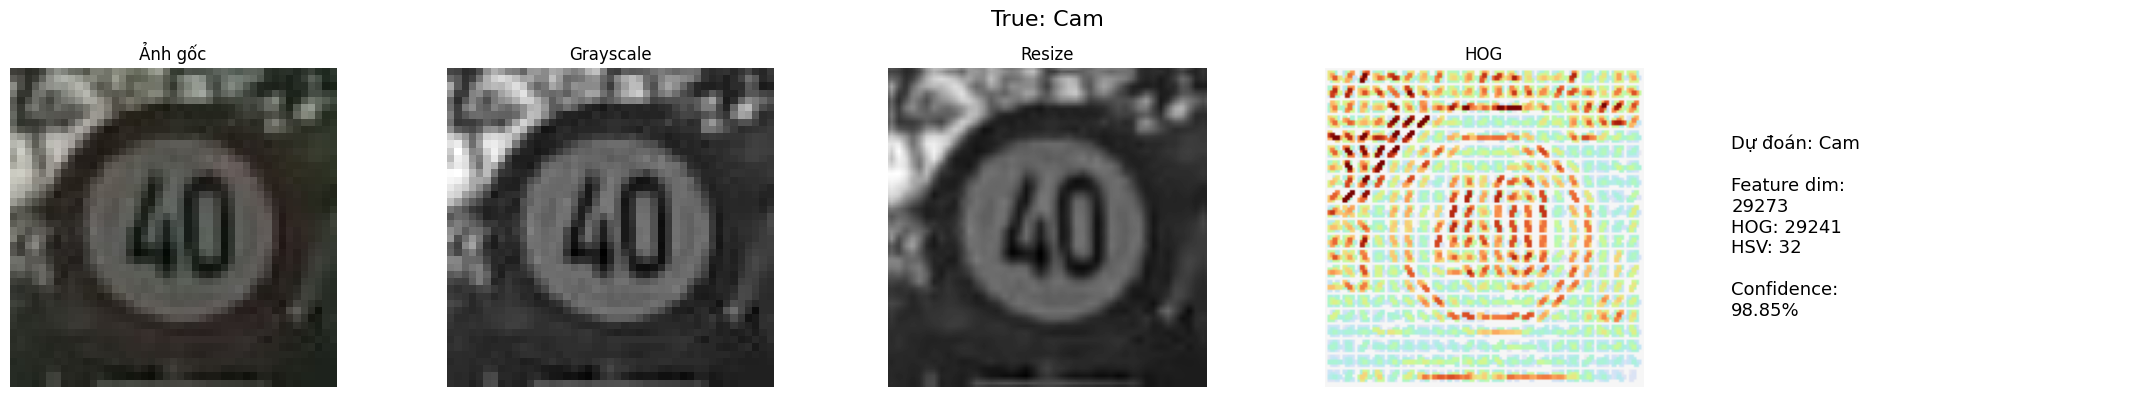

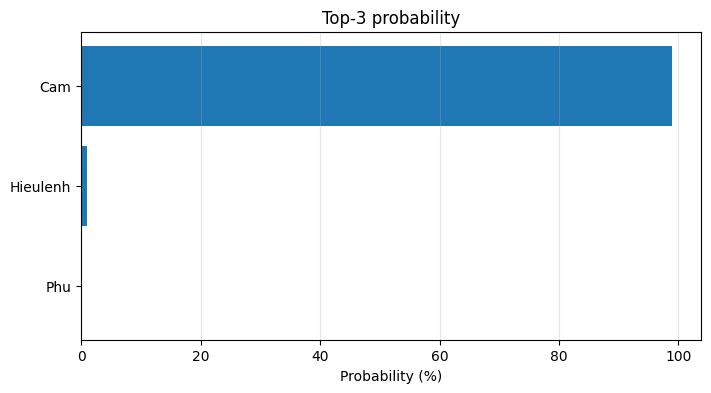

True: Cam | Pred: Cam | File: Cam_005.jpg


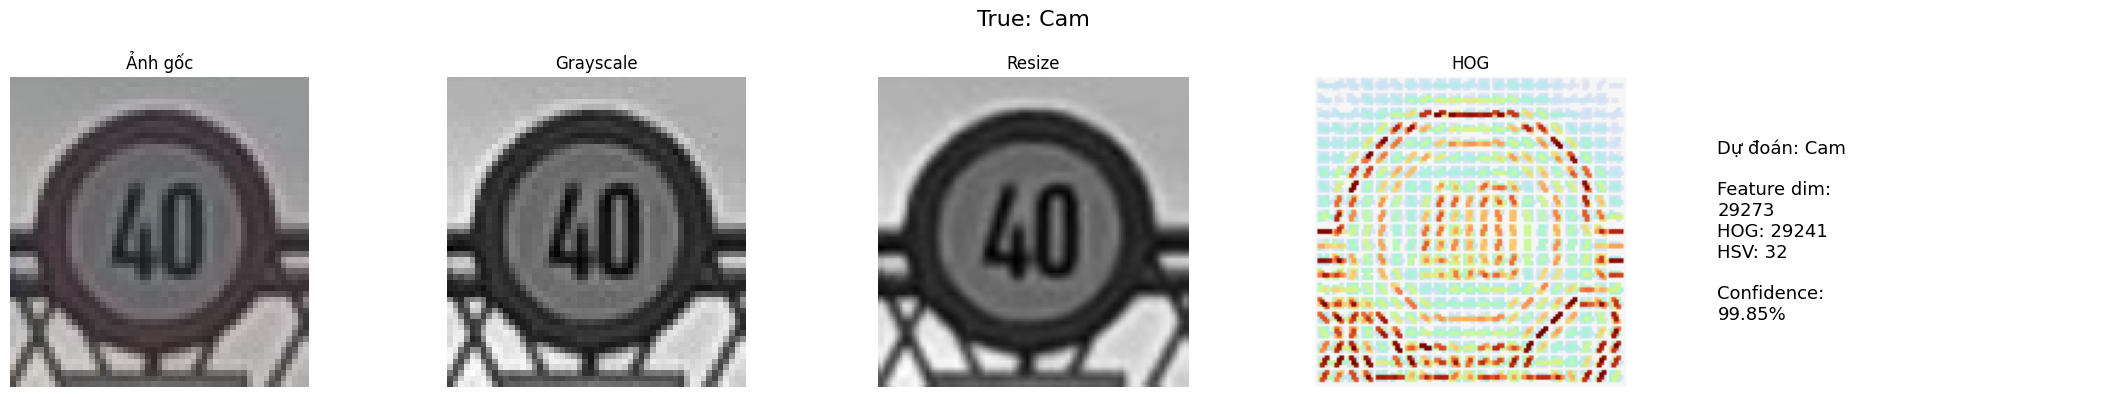

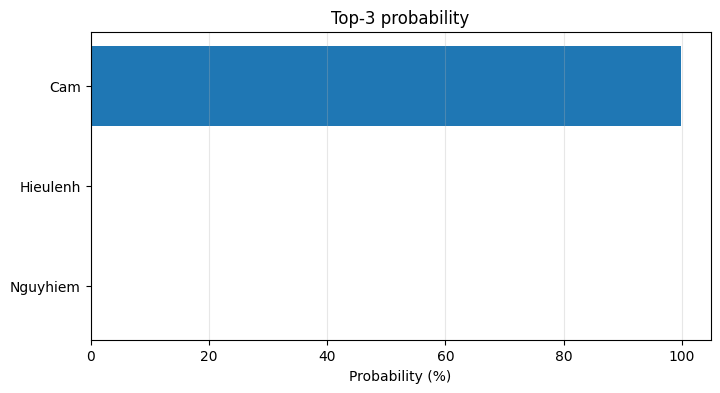

True: Cam | Pred: Cam | File: Cam_006.jpg


In [61]:
# Lấy tối đa n ảnh trong data/test để visualize nhanh
n_images = 6
image_paths = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
    image_paths.extend(TEST_DIR.rglob(ext))

image_paths = image_paths[:n_images]
print(f"Tìm thấy {len(image_paths)} ảnh để visualize")

for p in image_paths:
    true_label = p.parent.name
    pred = visualize_classification(
        p, model, le, IMAGE_SIZE, HOG_PARAMS,
        feature_extractor=FEATURE_EXTRACTOR,
        hsv_hist_bins=HSV_HIST_BINS,
        title=f"True: {true_label}",
        top_k=3,
    )
    print(f"True: {true_label} | Pred: {pred} | File: {p.name}")

## 10. So sánh visualization score của 4 model trên cùng một ảnh

In [62]:
def extract_feature_for_payload(image_path, payload):
    image_size = tuple(payload["image_size"])
    hog_params = payload["hog_params"]
    feature_extractor = payload.get("feature_extractor", "HOG")
    hsv_hist_bins = payload.get("hsv_hist_bins")
    if hsv_hist_bins is not None:
        hsv_hist_bins = tuple(hsv_hist_bins)
    feature_vec, _ = extract_model_feature(
        image_path,
        image_size,
        hog_params,
        feature_extractor,
        hsv_hist_bins,
    )
    return feature_vec.reshape(1, -1)

results = []
for key, fname in MODEL_FILES.items():
    model_path = MODELS_DIR / fname
    if not model_path.exists():
        print("Không thấy model:", model_path)
        continue

    pl = joblib.load(model_path)
    m = pl["model"]
    encoder = pl["label_encoder"]
    x_model = extract_feature_for_payload(IMAGE_PATH, pl)

    pred_enc = m.predict(x_model)[0]
    pred_label = encoder.inverse_transform([pred_enc])[0]
    scores, score_type = get_model_scores(m, x_model)

    confidence = None
    if scores is not None:
        confidence = scores[pred_enc]
        if score_type == "probability":
            confidence = confidence * 100

    results.append((key, pred_label, confidence, score_type))

print(f"Ảnh test: {IMAGE_PATH.name}")
print("-" * 80)
for key, pred_label, confidence, score_type in results:
    if confidence is None:
        print(f"{key:8s} | Pred: {pred_label}")
    else:
        suffix = "%" if score_type == "probability" else ""
        print(f"{key:8s} | Pred: {pred_label:25s} | {score_type}: {confidence:.4f}{suffix}")

Ảnh test: Nguyhiem_029.jpg
--------------------------------------------------------------------------------
RF_6x3   | Pred: Nguyhiem                  | probability: 90.7794%
RF_8x2   | Pred: Nguyhiem                  | probability: 89.2500%
SVM_6x3  | Pred: Nguyhiem                  | probability: 99.7939%
SVM_8x2  | Pred: Nguyhiem                  | probability: 99.8503%
